# Análise Exploratória de Filmes - IMDb Top 1000

Este projeto tem como objetivo realizar uma análise exploratória de dados utilizando o dataset IMDb Top 1000. A análise busca identificar padrões relacionados às avaliações dos filmes, popularidade, gêneros mais frequentes e evolução das produções ao longo do tempo.

As etapas realizadas incluem:
- exploração dos dados
- tratamento e limpeza
- criação de variáveis derivadas
- análises exploratórias
- geração de visualizações

## Importação das bibliotecas

Nesta etapa são importadas as bibliotecas necessárias para manipulação, análise e visualização dos dados.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Carregamento dos dados

O dataset utilizado contém informações sobre os 1000 filmes mais bem avaliados do IMDb, incluindo título, ano de lançamento, gênero, diretor, número de votos e avaliação média.

In [3]:
df = pd.read_csv("imdb_top_1000.csv")

df.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


## Exploração inicial

Nesta etapa verificamos a estrutura do dataset, tipos de dados e estatísticas gerais para compreender melhor as informações disponíveis.

In [19]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


,IMDB_Rating,Meta_score,No_of_Votes
count,1000.000000,843.000000,1.000000e+03
mean,7.949300,77.971530,2.736929e+05
std,0.275491,12.376099,3.273727e+05
min,7.600000,28.000000,2.508800e+04
25%,7.700000,70.000000,5.552625e+04
50%,7.900000,79.000000,1.385485e+05
75%,8.100000,87.000000,3.741612e+05
max,9.300000,100.000000,2.343110e+06


In [4]:
df.columns

Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='object')

## Estruturação das tabelas

Como o dataset original possui todas as informações em uma única tabela, os dados foram reorganizados em três tabelas distintas (filmes, avaliações e diretores). Essa abordagem simula um modelo relacional e permite realizar cruzamentos entre as informações.

In [5]:
movies = df[['Series_Title','Released_Year','Genre','Runtime']]

In [6]:
ratings = df[['Series_Title','IMDB_Rating','No_of_Votes']]

In [7]:
directors = df[['Series_Title','Director']]

## Integração das tabelas

Nesta etapa realizamos o cruzamento das tabelas utilizando o título do filme como chave de ligação.

In [8]:
df_final = movies.merge(ratings, on='Series_Title')
df_final = df_final.merge(directors, on='Series_Title')

df_final.head()

,Series_Title,Released_Year,Genre,Runtime,IMDB_Rating,No_of_Votes,Director
0,The Shawshank Redemption,1994,Drama,142 min,9.3,2343110,Frank Darabont
1,The Godfather,1972,"Crime, Drama",175 min,9.2,1620367,Francis Ford Coppola
2,The Dark Knight,2008,"Action, Crime, Drama",152 min,9.0,2303232,Christopher Nolan
3,The Godfather: Part II,1974,"Crime, Drama",202 min,9.0,1129952,Francis Ford Coppola
4,12 Angry Men,1957,"Crime, Drama",96 min,9.0,689845,Sidney Lumet


## Tratamento e limpeza dos dados

Foram removidos valores ausentes e ajustados formatos de colunas para garantir consistência na análise.

In [9]:
df_final = df_final.dropna()

In [10]:
df_final['Released_Year'] = pd.to_numeric(df_final['Released_Year'], errors='coerce')

## Criação de variáveis derivadas

Foram criadas novas colunas para enriquecer a análise:

- Década de lançamento
- Índice de popularidade baseado em votos e avaliação

In [11]:
df_final['Decade'] = (df_final['Released_Year']//10)*10

In [12]:
df_final['Popularity'] = df_final['IMDB_Rating'] * df_final['No_of_Votes']

## Análise exploratória

Nesta etapa são realizadas análises visuais para identificar padrões e relações entre as variáveis do dataset.

### Distribuição das avaliações dos filmes

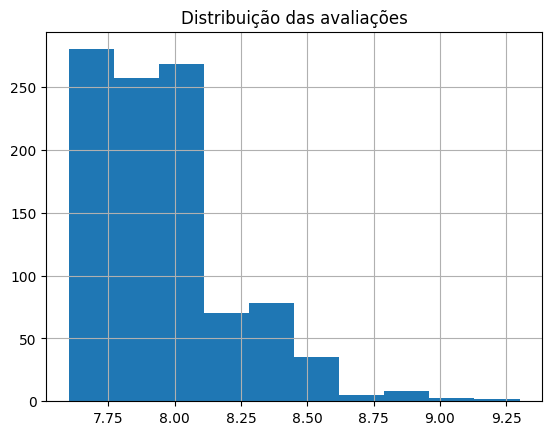

In [20]:
df_final['IMDB_Rating'].hist()
plt.title("Distribuição das avaliações")
plt.show()

### Quantidade de filmes lançados por ano

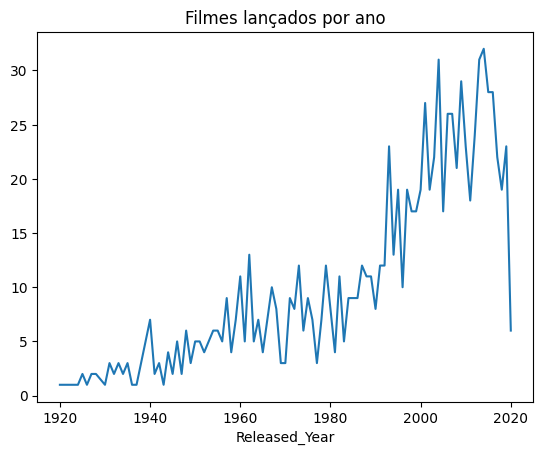

In [21]:
df_final.groupby('Released_Year').size().plot()
plt.title("Filmes lançados por ano")
plt.show()

### Gêneros mais frequentes

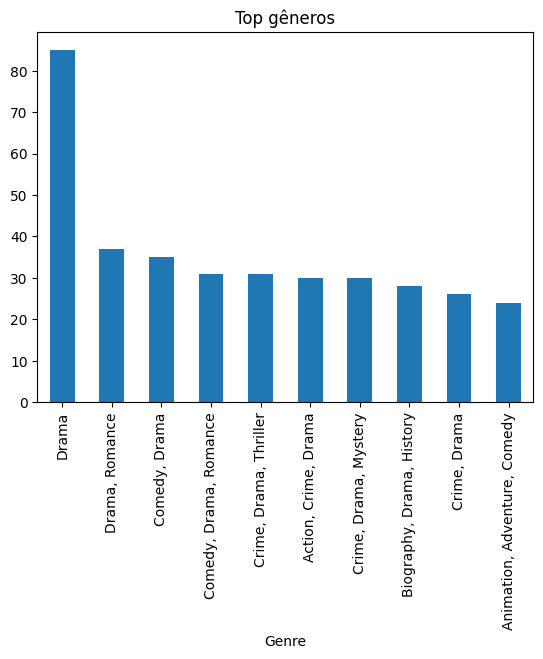

In [22]:
df_final['Genre'].value_counts().head(10).plot(kind='bar')
plt.title("Top gêneros")
plt.show()

### Relação entre número de votos e avaliação

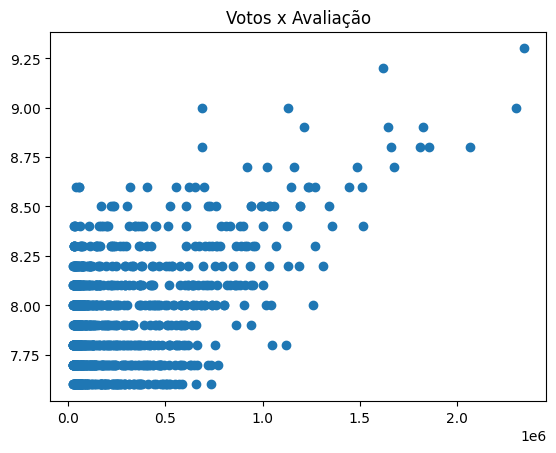

In [23]:
plt.scatter(df_final['No_of_Votes'], df_final['IMDB_Rating'])
plt.title("Votos x Avaliação")
plt.show()

### Filmes com maiores avaliações

In [30]:
top_filmes = df_final.sort_values('IMDB_Rating', ascending=False).head(10)
top_filmes[['Series_Title','IMDB_Rating']]

,Series_Title,IMDB_Rating
0,The Shawshank Redemption,9.3
1,The Godfather,9.2
2,The Dark Knight,9.0
3,The Godfather: Part II,9.0
4,12 Angry Men,9.0
7,Schindler's List,8.9
6,Pulp Fiction,8.9
5,The Lord of the Rings: The Return of the King,8.9
11,Forrest Gump,8.8
8,Inception,8.8


In [32]:
df['Released_Year'] = pd.to_numeric(df['Released_Year'], errors='coerce')
df = df.dropna(subset=['Released_Year'])
df['Released_Year'] = df['Released_Year'].astype(int)

In [33]:
df_final.to_csv("imdb_tratado.csv", index=False)

## Conclusão

A análise exploratória permitiu identificar padrões relevantes no dataset. Foi possível observar a distribuição das avaliações, a evolução da produção de filmes ao longo do tempo e os gêneros mais frequentes. Além disso, a relação entre número de votos e avaliação demonstra que filmes mais populares tendem a apresentar avaliações mais altas.

Os resultados desta análise serão utilizados para construção de um dashboard interativo no Looker Studio, permitindo uma visualização mais clara e dinâmica dos insights obtidos.